In [4]:
import tensorflow as tf, keras_cv, pathlib, os, PIL, json, random, numpy as np, matplotlib.pyplot as plt

In [5]:
# Definição de Parâmetros
IMG_SIZE       = (100, 100)
BATCH_SIZE     = 32
NUM_EPOCHS     = 25
VAL_SPLIT      = 0.2
SEED           = 123
AUTOTUNE       = tf.data.AUTOTUNE

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

In [7]:
DATA_DIR = pathlib.Path('/kaggle/input/fruits/fruits-360_100x100/fruits-360')

assert DATA_DIR.exists(), f"{DATA_DIR} not found — check the dataset path!"

# Carregar dados de treino e validação
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    DATA_DIR / 'Training',
    labels='inferred',
    label_mode='categorical',
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    validation_split=VAL_SPLIT,
    subset='training',
    seed=SEED
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    DATA_DIR / 'Training',
    labels='inferred',
    label_mode='categorical',
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    validation_split=VAL_SPLIT,
    subset='validation',
    seed=SEED
)

# Carregar classes
class_names = train_ds.class_names
NUM_CLASSES = len(class_names)
print("Classes:", NUM_CLASSES)

# Dataset de teste
test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    DATA_DIR / 'Test',
    labels='inferred',
    label_mode='categorical',
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

Found 103993 files belonging to 206 classes.
Using 83195 files for training.


I0000 00:00:1750186814.394268      35 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1750186814.395002      35 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Found 103993 files belonging to 206 classes.
Using 20798 files for validation.
Classes: 206
Found 34711 files belonging to 206 classes.


In [12]:
def configure(ds):
    return (ds.cache()
              .shuffle(1024, seed=SEED)
              .prefetch(AUTOTUNE))

train_ds = configure(train_ds)
val_ds   = configure(val_ds)

In [13]:
augmenter = tf.keras.Sequential([
    tf.keras.layers.RandomFlip(mode='horizontal'),
    tf.keras.layers.RandomRotation(0.10),
    tf.keras.layers.RandomZoom(0.10),
], name='augmentation')

In [15]:
from tensorflow.keras import layers, models

base = tf.keras.applications.EfficientNetV2S(
    include_top=False,
    weights='imagenet',
    input_shape=IMG_SIZE + (3,),
    pooling='avg'
)
base.trainable = False

inputs  = layers.Input(shape=IMG_SIZE + (3,))
x       = augmenter(inputs)
x       = tf.keras.applications.efficientnet_v2.preprocess_input(x)
x       = base(x, training=False)
x       = layers.Dropout(0.30)(x)
outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)

model = models.Model(inputs, outputs, name='EffNetV2S_Fruits360')
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

82420632/82420632 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "EffNetV2S_Fruits360"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)           │ (None, 100, 100, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ augmentation (Sequential)            │ (None, 100, 100, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ efficientnetv2-s (Functional)        │ (None, 1280)                │      20,331,360 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 1280)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 206)                 │         263,886 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 20,595,246 (78.56 MB)

 Trainable params: 263,886 (1.01 MB)

 Non-trainable params: 20,331,360 (77.56 MB)

In [16]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(patience=3)
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=NUM_EPOCHS,
    callbacks=callbacks)

Epoch 1/25


E0000 00:00:1750187063.721384      35 meta_optimizer.cc:966] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/EffNetV2S_Fruits360_1/efficientnetv2-s_1/block1b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer
I0000 00:00:1750187155.006987     130 cuda_dnn.cc:529] Loaded cuDNN version 90300


2600/2600 ━━━━━━━━━━━━━━━━━━━━ 296s 67ms/step - accuracy: 0.6522 - loss: 1.8422 - val_accuracy: 0.9528 - val_loss: 0.2547 - learning_rate: 0.0010
Epoch 2/25
2600/2600 ━━━━━━━━━━━━━━━━━━━━ 144s 55ms/step - accuracy: 0.9347 - loss: 0.3025 - val_accuracy: 0.9755 - val_loss: 0.1281 - learning_rate: 0.0010
Epoch 3/25
2600/2600 ━━━━━━━━━━━━━━━━━━━━ 144s 55ms/step - accuracy: 0.9554 - loss: 0.1900 - val_accuracy: 0.9850 - val_loss: 0.0843 - learning_rate: 0.0010
Epoch 4/25
2600/2600 ━━━━━━━━━━━━━━━━━━━━ 144s 55ms/step - accuracy: 0.9611 - loss: 0.1497 - val_accuracy: 0.9852 - val_loss: 0.0674 - learning_rate: 0.0010
Epoch 5/25
2600/2600 ━━━━━━━━━━━━━━━━━━━━ 144s 55ms/step - accuracy: 0.9670 - loss: 0.1224 - val_accuracy: 0.9897 - val_loss: 0.0500 - learning_rate: 0.0010
Epoch 6/25
2600/2600 ━━━━━━━━━━━━━━━━━━━━ 144s 55ms/step - accuracy: 0.9680 - loss: 0.1124 - val_accuracy: 0.9896 - val_loss: 0.0441 - learning_rate: 0.0010
Epoch 7/25
2600/2600 ━━━━━━━━━━━━━━━━━━━━ 144s 55ms/step - accuracy: 

In [18]:
base.trainable = True
for layer in base.layers[:-40]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy'])

fine_tune_epochs = 20
history_ft = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=fine_tune_epochs,
    callbacks=callbacks)

Epoch 1/20


E0000 00:00:1750191049.245258      35 meta_optimizer.cc:966] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/EffNetV2S_Fruits360_1/efficientnetv2-s_1/block1b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


2600/2600 ━━━━━━━━━━━━━━━━━━━━ 218s 69ms/step - accuracy: 0.9595 - loss: 0.1267 - val_accuracy: 0.9961 - val_loss: 0.0115 - learning_rate: 1.0000e-04
Epoch 2/20
2600/2600 ━━━━━━━━━━━━━━━━━━━━ 170s 65ms/step - accuracy: 0.9853 - loss: 0.0458 - val_accuracy: 0.9963 - val_loss: 0.0103 - learning_rate: 1.0000e-04
Epoch 3/20
2600/2600 ━━━━━━━━━━━━━━━━━━━━ 169s 65ms/step - accuracy: 0.9885 - loss: 0.0325 - val_accuracy: 0.9978 - val_loss: 0.0068 - learning_rate: 1.0000e-04
Epoch 4/20
2600/2600 ━━━━━━━━━━━━━━━━━━━━ 170s 65ms/step - accuracy: 0.9908 - loss: 0.0268 - val_accuracy: 0.9985 - val_loss: 0.0041 - learning_rate: 1.0000e-04
Epoch 5/20
2600/2600 ━━━━━━━━━━━━━━━━━━━━ 169s 65ms/step - accuracy: 0.9922 - loss: 0.0239 - val_accuracy: 0.9939 - val_loss: 0.0146 - learning_rate: 1.0000e-04
Epoch 6/20
2600/2600 ━━━━━━━━━━━━━━━━━━━━ 171s 66ms/step - accuracy: 0.9928 - loss: 0.0204 - val_accuracy: 0.9980 - val_loss: 0.0052 - learning_rate: 1.0000e-04
Epoch 7/20
2600/2600 ━━━━━━━━━━━━━━━━━━━━ 171

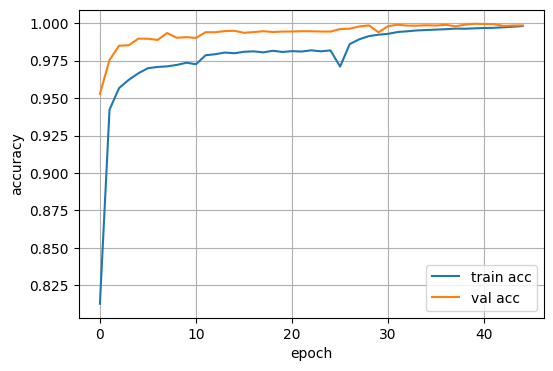

In [19]:
import pandas as pd

def plot_history(h1, h2=None):
    def _df(h):
        return pd.DataFrame(h.history)
    df1 = _df(h1)
    df = df1 if h2 is None else pd.concat([df1, _df(h2)], ignore_index=True)
    fig, ax = plt.subplots(figsize=(6,4))
    ax.plot(df['accuracy'], label='train acc')
    ax.plot(df['val_accuracy'], label='val acc')
    ax.set_xlabel('epoch'); ax.set_ylabel('accuracy'); ax.legend(); ax.grid();
    plt.show()

plot_history(history, history_ft)

In [21]:
test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    DATA_DIR / 'Test',
    labels='inferred',
    label_mode='categorical',
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False)

test_ds = test_ds.cache().prefetch(AUTOTUNE)

loss, acc = model.evaluate(test_ds)
print(f"Test accuracy: {acc:.3%}")

Found 34711 files belonging to 206 classes.
1085/1085 ━━━━━━━━━━━━━━━━━━━━ 49s 45ms/step - accuracy: 0.9895 - loss: 0.0399
Test accuracy: 98.897%


1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step


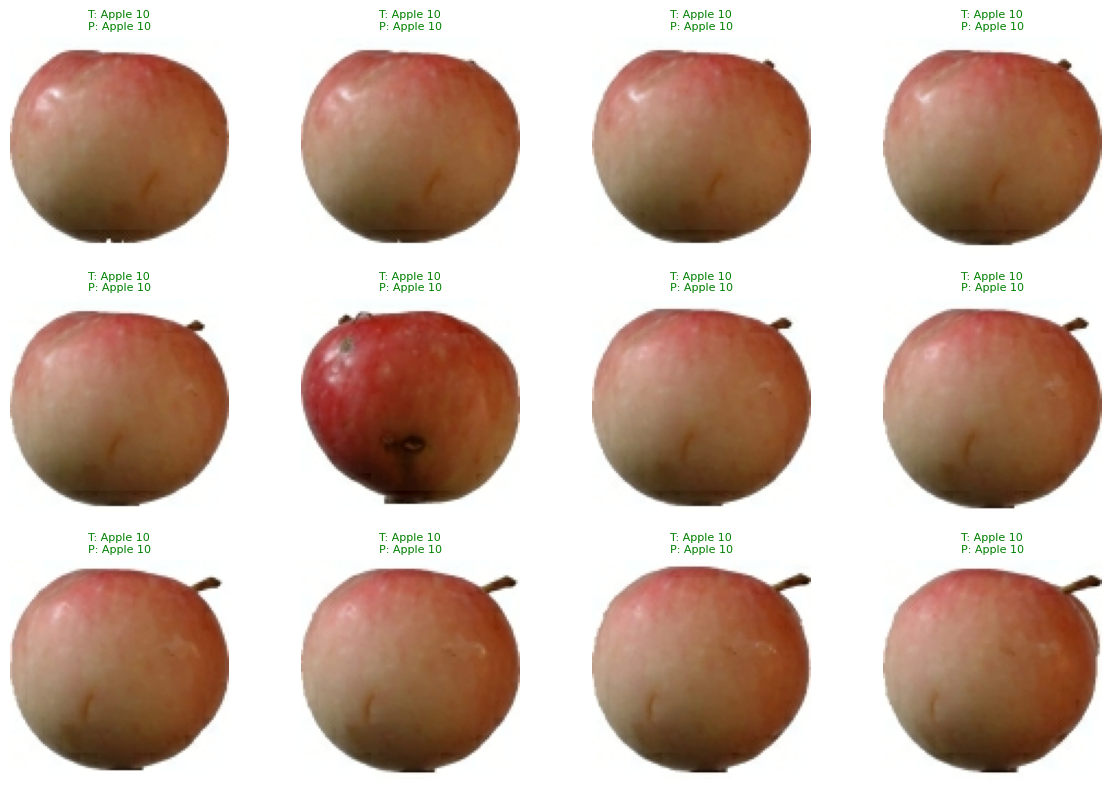

In [22]:
import itertools
class_indices = {v:k for k,v in enumerate(class_names)}

plt.figure(figsize=(12, 8))
for i, (imgs, labels) in enumerate(test_ds.take(1)):
    preds = model.predict(imgs)
    for j in range(12):
        ax = plt.subplot(3, 4, j+1)
        img = imgs[j].numpy().astype("uint8")
        true_lbl  = class_names[tf.argmax(labels[j]).numpy()]
        pred_lbl  = class_names[tf.argmax(preds[j]).numpy()]
        color = 'green' if true_lbl == pred_lbl else 'red'
        plt.imshow(img)
        plt.title(f"T: {true_lbl}\nP: {pred_lbl}", color=color, fontsize=8)
        plt.axis('off')
plt.tight_layout()

In [24]:
MODEL_DIR = "/kaggle/working/effnetv2_fruits360"
model.save("/kaggle/working/effnetv2_fruits360.h5")
print("Model saved to", MODEL_DIR)

Model saved to /kaggle/working/effnetv2_fruits360


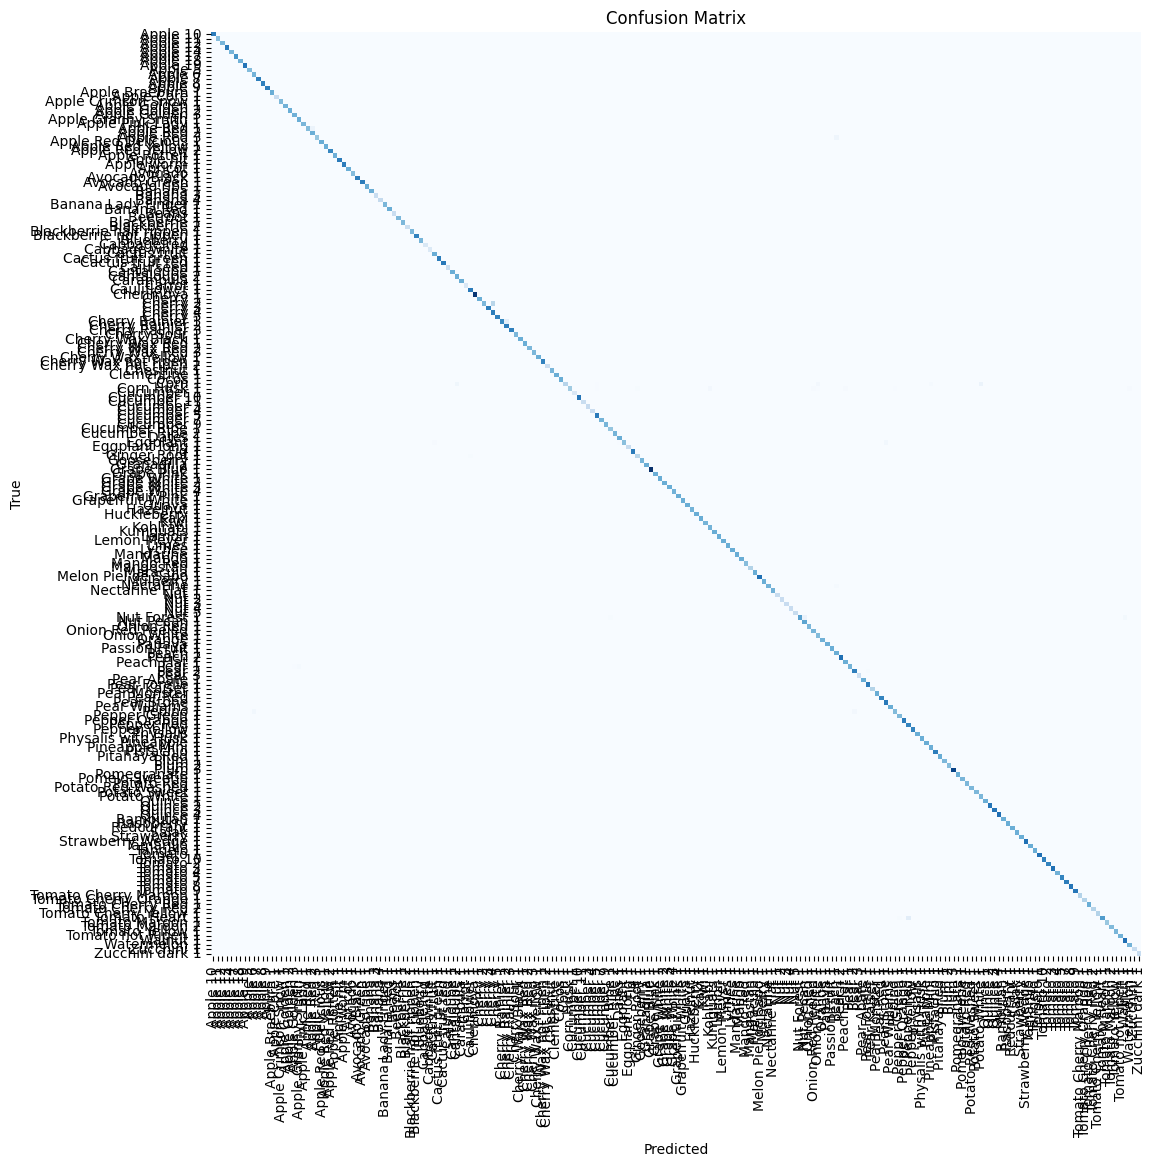

In [25]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Get true & predicted labels for the entire test set
true_labels = []
pred_labels = []
for imgs, lbls in test_ds:
    preds = model.predict(imgs, verbose=0)
    true_labels.extend(tf.argmax(lbls, axis=1).numpy())
    pred_labels.extend(tf.argmax(preds, axis=1).numpy())

cm = confusion_matrix(true_labels, pred_labels)

plt.figure(figsize=(12, 12))
ax = sns.heatmap(cm, annot=False, fmt='d', cmap='Blues', cbar=False,
                 xticklabels=class_names, yticklabels=class_names)
ax.set_xlabel('Predicted'); ax.set_ylabel('True'); ax.set_title('Confusion Matrix');
plt.xticks(rotation=90); plt.yticks(rotation=0);
plt.show()